In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import tqdm as tqdm

# Special for plotting
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# Import OpenSense modules as submodules
import sys
import os

sys.path.append(os.path.abspath("./pycomlink/"))
sys.path.append(os.path.abspath("./poligrain/src/"))
sys.path.append(os.path.abspath("./mergeplg/src/"))

import pycomlink as pycml 
import poligrain as plg
import mergeplg

/home/erlend/git/radar_adjustment_intercomparison/pycomlink/pycomlink/io/examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# OpenRainER

In [4]:
# OpenRainER
ds_gauges = xr.open_dataset("data/covi_2024_OpenRainER/AWS_rainfall.nc")
ds_rad = xr.open_dataset("data/covi_2024_OpenRainER/openrainer_radar.nc")
ds_cmls = xr.open_dataset("data/processed_cml_OpenRainER.nc") 
rad_along = xr.open_dataset('data/covi_2024_OpenRainER/RADadj_along_cml.nc')

# Resample to 15 min resolution
ds_cmls = ds_cmls.R_acc.resample(time = '15min', label='right', closed='right').sum(skipna=True)
ds_cmls = ds_cmls.reduce(np.nanmean, dim='sublink_id')

# Slice in time 
start = '2022-08-18T08'
end = '2022-08-18T10'
ds_gauges = ds_gauges.sel(time = slice(start, end))
ds_rad = ds_rad.sel(time = slice(start, end)) 
ds_cmls = ds_cmls.sel(time = slice(start, end)) 
rad_along = rad_along.sel(time = slice(start, end)) 

In [5]:
rad_along = rad_along.sel(cml_id = ds_cmls.cml_id)
rad_along['rainfall_amount'] = rad_along['rainfall_amount'].transpose("cml_id", "time").reset_coords(drop=True)
ds_cmls['rainfall_radar'] = rad_along['rainfall_amount']

In [6]:
# Threshold lower values
radar_zero = 0.01  # here in sum mm over 15 minutes
ds_rad["rainfall_amount"] = xr.where(
    ds_rad.rainfall_amount > radar_zero, ds_rad.rainfall_amount, 0
)

In [7]:
ref_str = "EPSG:32632"

# Project OpenRainER data
ds_gauges.coords["x"], ds_gauges.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges.longitude, ds_gauges.latitude, ref_str
)

(
    ds_cmls.coords["site_0_x"],
    ds_cmls.coords["site_0_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, ref_str
)
(
    ds_cmls.coords["site_1_x"],
    ds_cmls.coords["site_1_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, ref_str
)

# Midpoint
ds_cmls.coords["x"] = (ds_cmls.site_0_x + ds_cmls.site_1_x) / 2
ds_cmls.coords["y"] = (ds_cmls.site_0_y + ds_cmls.site_1_y) / 2

# Projected radar coords
ds_rad.coords["x_grid"], ds_rad.coords["y_grid"] = plg.spatial.project_point_coordinates( 
    ds_rad.lon_grid, ds_rad.lat_grid, ref_str
)


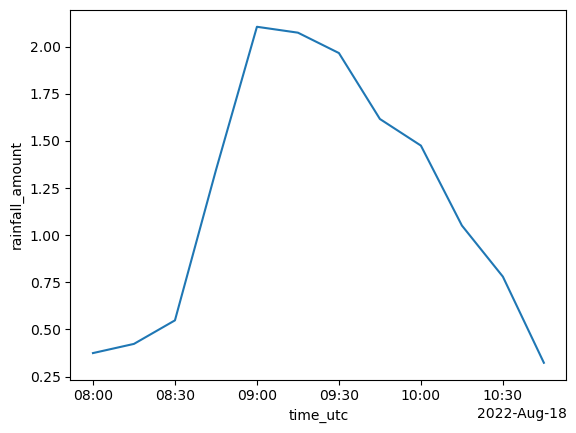

In [8]:
ds_gauges.rainfall_amount.mean(dim = 'id').plot()

In [11]:
np.random.choice?

Signature: np.random.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a
    single value is retur

In [26]:
train_test_split = 0.7
np.random.seed(0)

# Do split
total_id = np.arange(ds_gauges.id.size)
np.random.shuffle(total_id)
train_id = total_id[:int(train_test_split*total_id.size)]
test_id = np.array([i for i in total_id if i not in train_id])
ds_gauges_test = ds_gauges.isel(id = test_id).copy()
ds_gauges = ds_gauges.isel(id = train_id).copy()

# interpolate rain gauges

In [119]:
variogram_parameters = {"sill": 0.9, "range": 10000, "nugget": 0.4}
nnear = 12

merger = mergeplg.interpolate.InterpolateOrdinaryKriging(
    ds_grid=ds_rad, # can be replaced with a custom grid
    ds_gauges=ds_gauges,
    full_line=False,
    variogram_parameters=variogram_parameters,
    nnear=nnear,
)

rainfall = []
for time in ds_gauges.time.data:
    rainfall.append(
        merger(
            da_gauges=ds_gauges.rainfall_amount.sel(time=time),
        )
    )
ds_rad["rainfall_interpolateBKpoint"] = xr.concat(rainfall, dim="time")


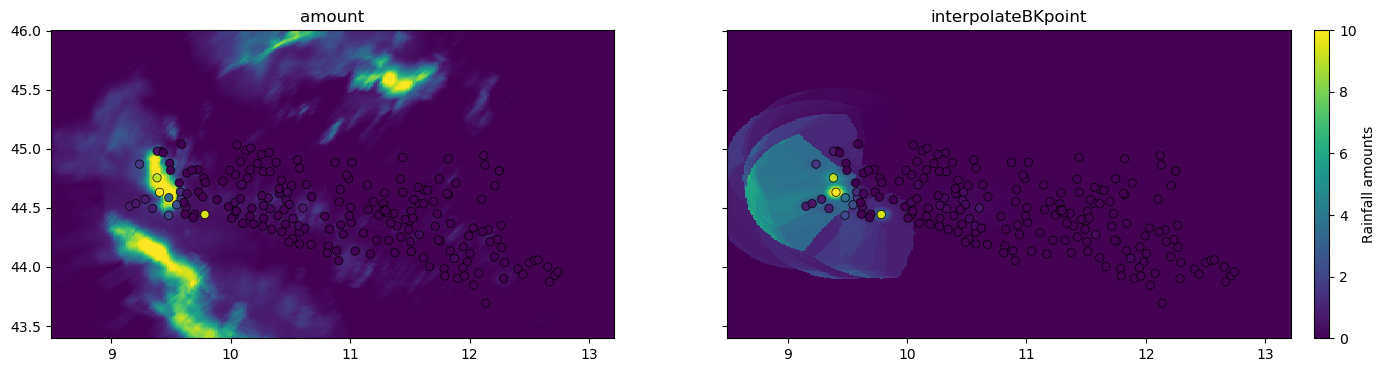

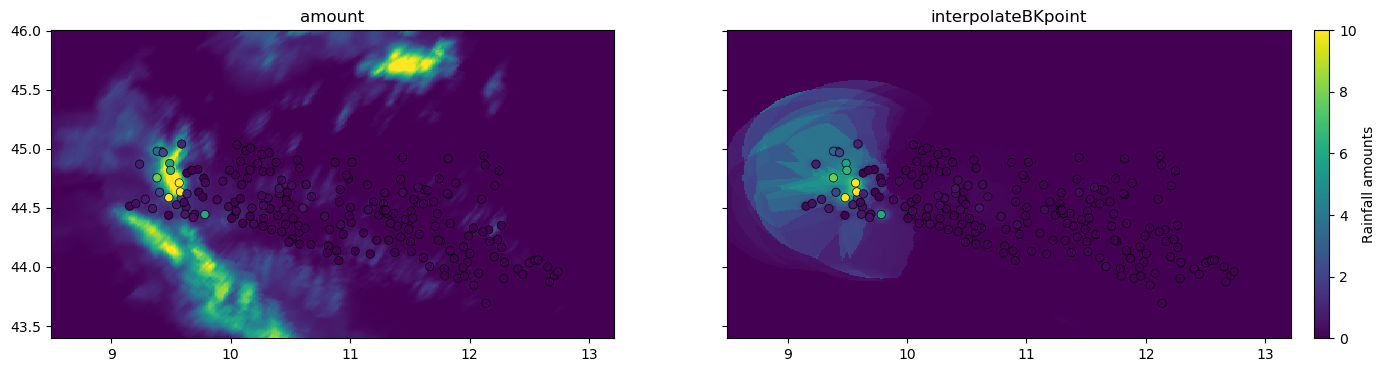

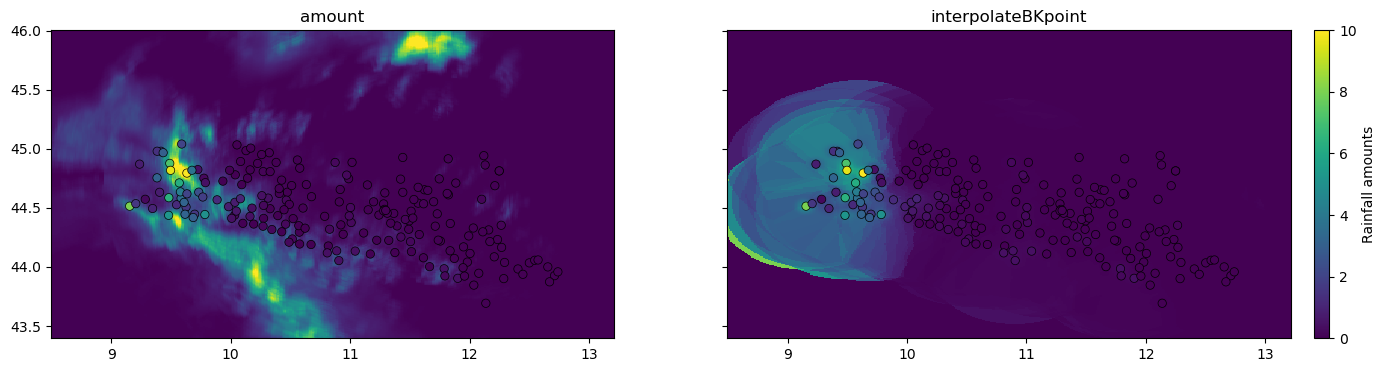

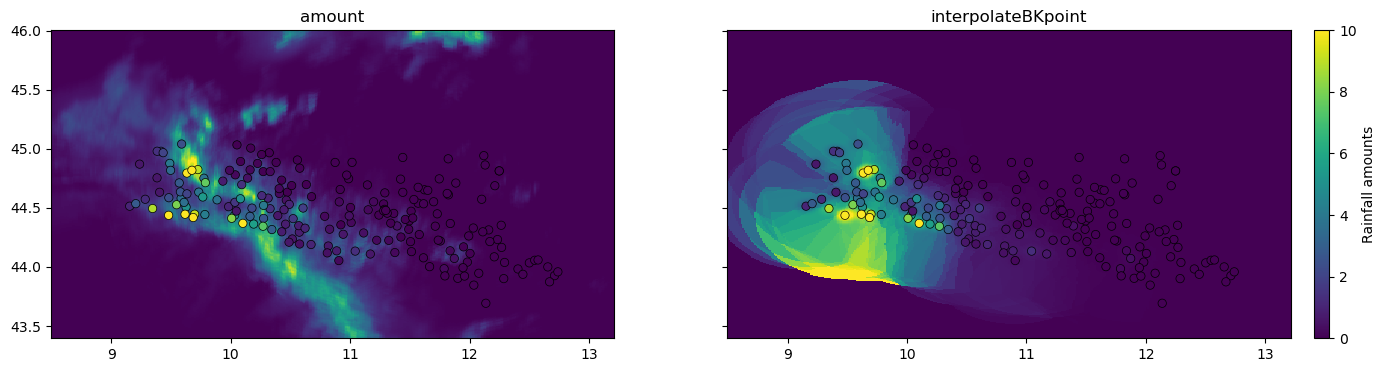

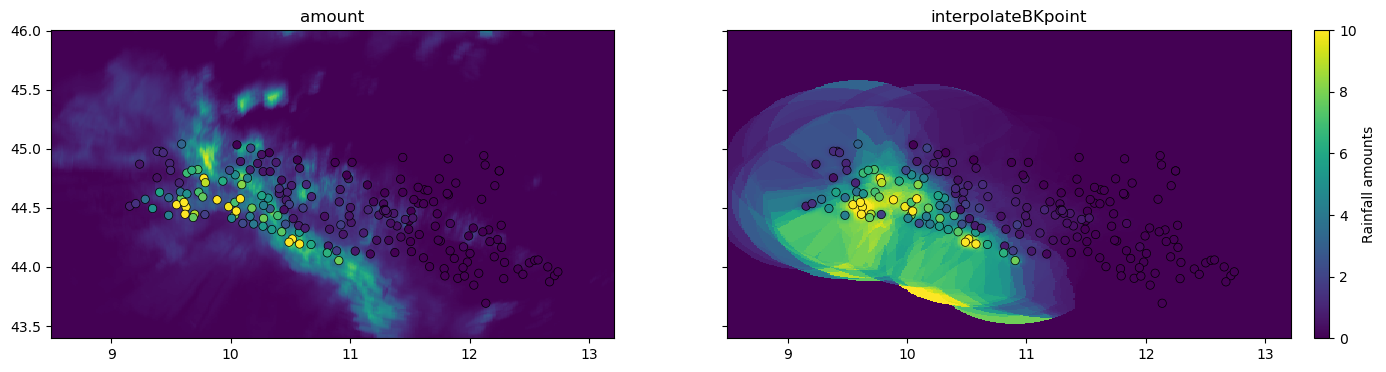

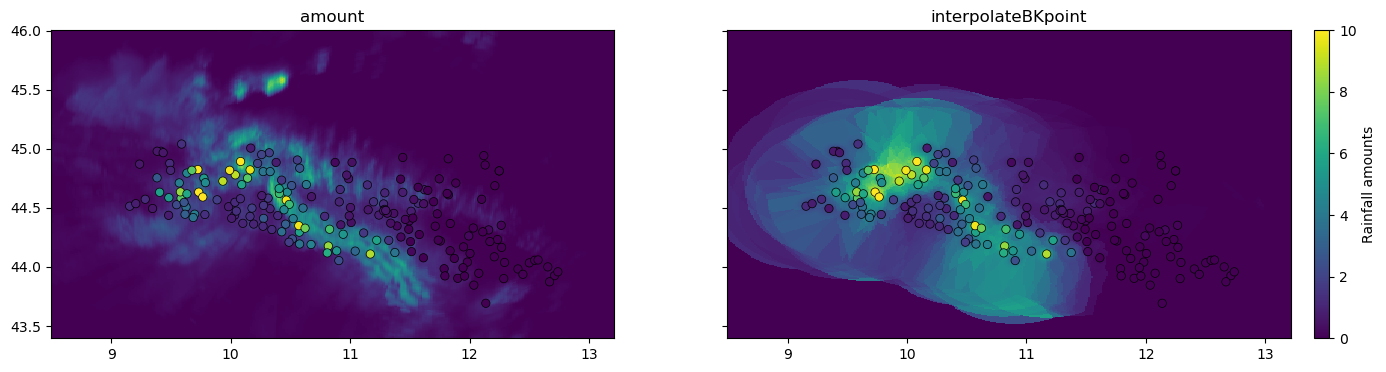

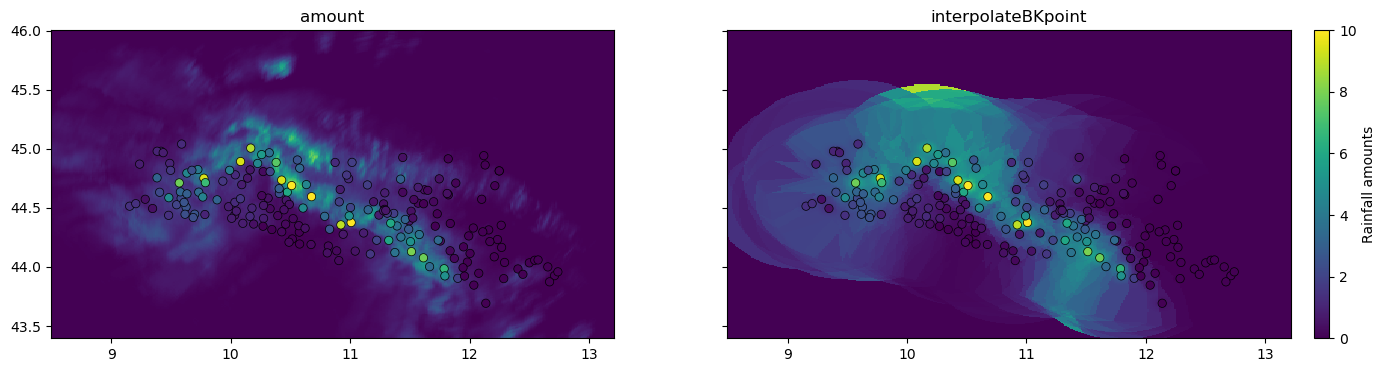

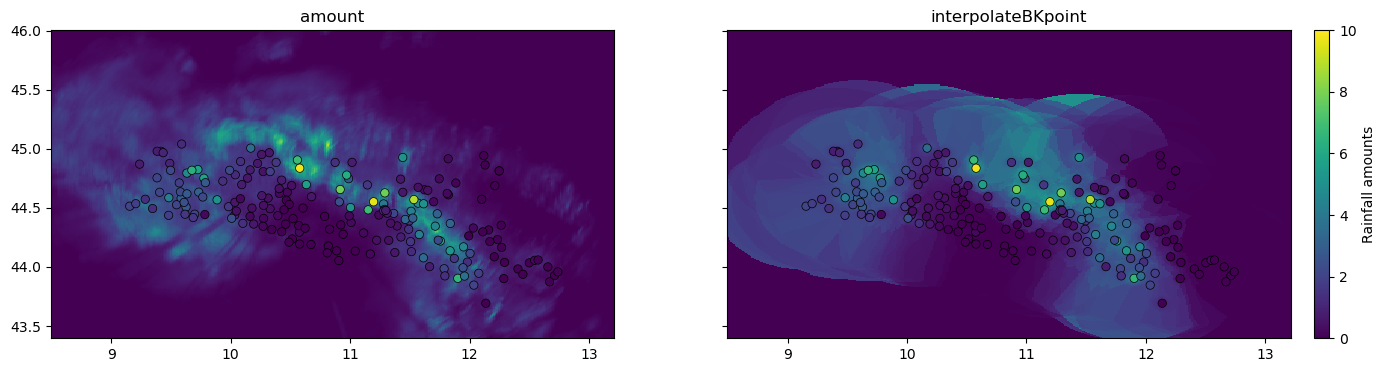

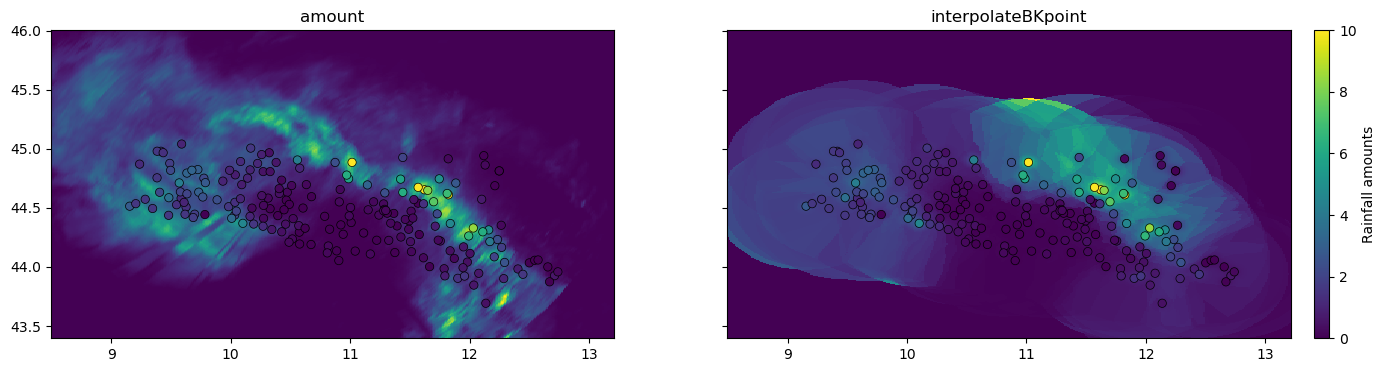

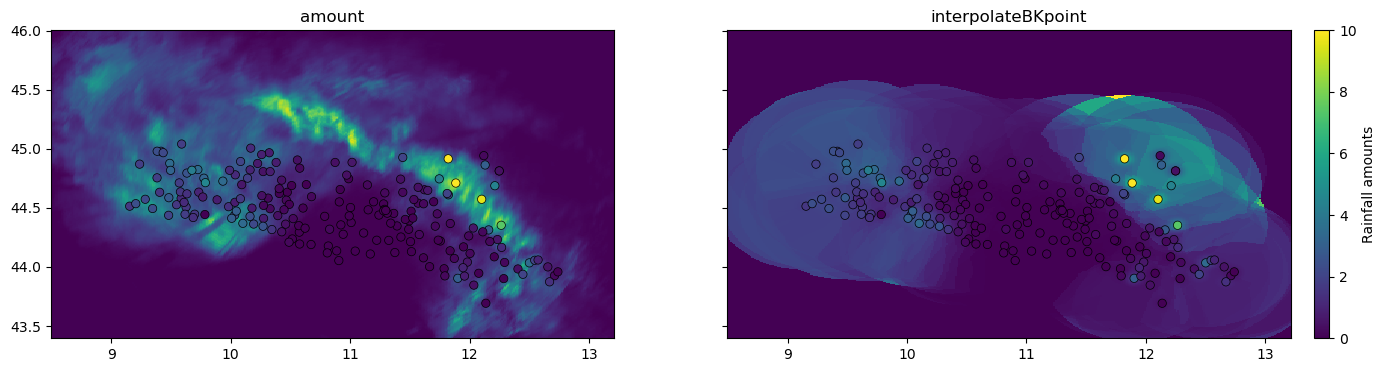

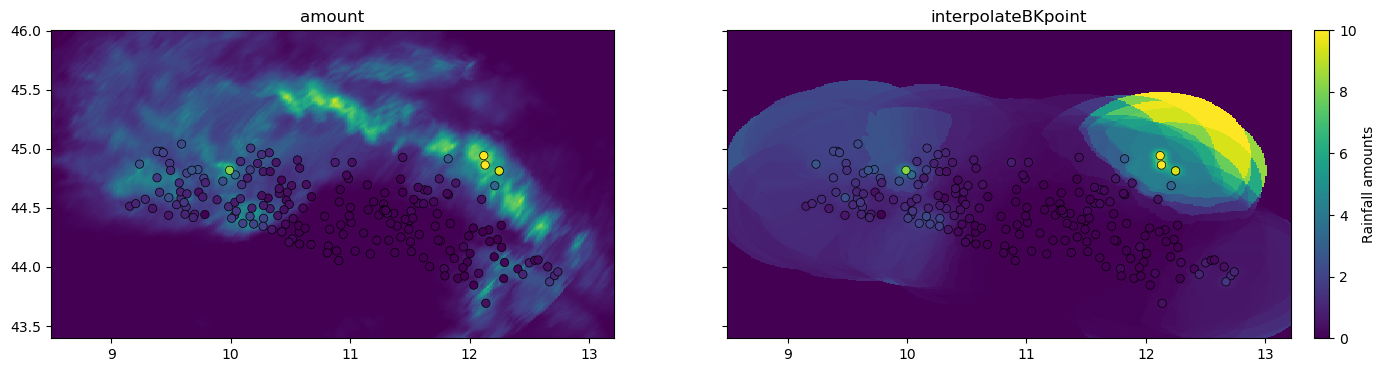

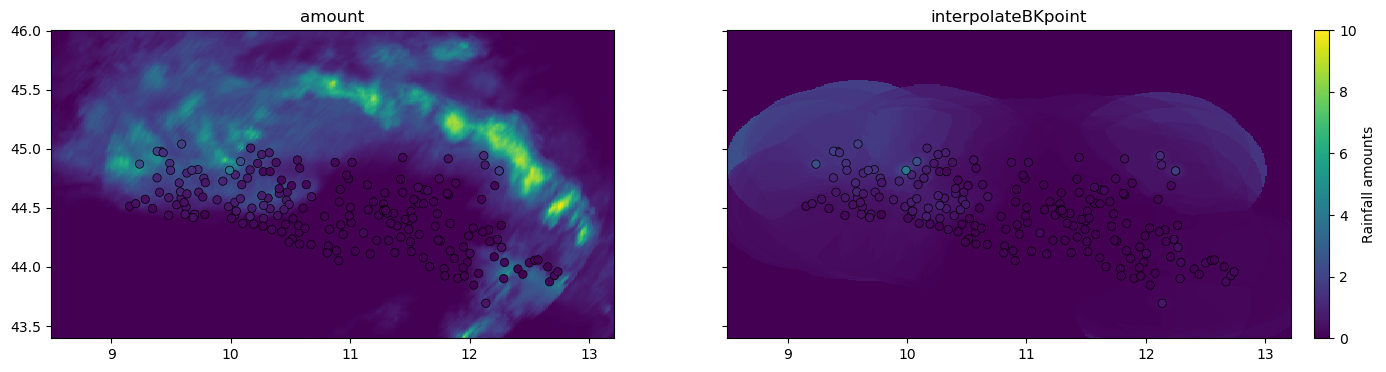

In [120]:
vmax = 10  # max color
cmap_rain = "viridis"
# Time interval to plot
time_start = start
time_end = end
# Rainfall fields to plot
rainfall_fields = [
    "rainfall_amount",
    "rainfall_interpolateBKpoint",
]

for time in ds_cmls.sel(time=slice(time_start, time_end)).time:
    fig, ax = plt.subplots(1, len(rainfall_fields), figsize=(20, 4), sharey=True)
    for i, rainfall_field in enumerate(rainfall_fields):
        # Plot rainfall field
        im = ax[i].pcolormesh(
            ds_rad.lon,
            ds_rad.lat,
            ds_rad[rainfall_field].sel(time=time),
            vmin=0,
            vmax=vmax,
            cmap=cmap_rain,
        )
        ax[i].scatter(
            ds_gauges.longitude, 
            ds_gauges.latitude, 
            c=ds_gauges.sel(time=time).rainfall_amount, 
            vmin=0, 
            vmax=vmax,
            edgecolors='black',  # Add a black outline
            linewidth=0.5        # Adjust the thickness of the outline
        )
        

        ax[i].set_title(rainfall_field.split("_")[1])

    clb = fig.colorbar(im, ax=ax, location="right", anchor=(-0.25, 1.0))
    clb.ax.set_ylabel("Rainfall amounts")
    plt.show()

    

# advection..

In [121]:
from pysteps.motion.lucaskanade import dense_lucaskanade

In [501]:
# Time step to interpolate
t_target = 6
t_back = 5 # Number of timesteps to go back in time
t_forw = 5 # Number of timesteps to go forward in time

time_target = ds_gauges.isel(time = t_target).time
time_start = ds_gauges.isel(time = t_target - t_back).time
time_end = ds_gauges.isel(time = t_target + t_forw).time

In [502]:
# Compute motion field (u, v) using Lucas-Kanade
motion_field = dense_lucaskanade(ds_rad.sel(time = slice(time_start, time_end)).rainfall_amount)
u, v = motion_field[0], motion_field[1]  # Mot

In [718]:
# Time step to interpolate
t_target = 5
t_back = 3 # Number of timesteps to go back in time
t_forw = 3 # Number of timesteps to go forward in time

time_target = ds_gauges.isel(time = t_target).time
time_start = ds_gauges.isel(time = t_target - t_back).time
time_end = ds_gauges.isel(time = t_target + t_forw).time

In [719]:
# Rain gauge coordinates (longitude, latitude)
coords = np.zeros([t_back+t_forw+1, ds_gauges.x.size, 2])

# Set target coordinates
coords[t_back, :, 0] = ds_gauges.y
coords[t_back, :, 1] = ds_gauges.x

# Grid data for fast access
x_grid = ds_rad.x_grid.data
y_grid = ds_rad.y_grid.data

# Time step duration in seconds
dt = 1000  # size of each cell [m]

# Backtrack the rain gauge locations
for t in reversed(range(1, t_back+1)):  
    y0 = coords[t, :, 0]
    x0 = coords[t, :, 1]
    
    # Array for storing index of observations
    yx_index = np.zeros([x0.size, 2]).astype(int)

    # Distances for all obs to all gridpoints (fast ish)
    distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)

    # Get grid location
    for gauge_i in range(x0.size):
        index = np.argmin(distances[gauge_i])
        yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)

    dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
    dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
    
    coords[t-1, :, 0] = coords[t, :, 0] + dy  # Adjust latitude
    coords[t-1, :, 1] = coords[t, :, 1] + dx  # Adjust longitude

# Shift forward
for t in range(t_back, t_back+t_forw): 
    y0 = coords[t, :, 0]
    x0 = coords[t, :, 1]
    
    # Array for storing index of observations
    yx_index = np.zeros([x0.size, 2]).astype(int)

    # Distances for all obs to all gridpoints (fast ish)
    distances = np.sqrt((x0.reshape(-1, 1, 1) - x_grid)**2 + (y0.reshape(-1, 1, 1) - y_grid)**2)

    # Get grid location
    for gauge_i in range(x0.size):
        index = np.argmin(distances[gauge_i])
        yx_index[gauge_i, 0], yx_index[gauge_i, 1] = np.unravel_index(index, x_grid.shape)

    dx = u[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in x-direction
    dy = v[yx_index[:, 0], yx_index[:, 1]] * dt  # Displacement in y-direction
    
    coords[t+1, :, 0] = coords[t, :, 0] - dy  # Adjust latitude
    coords[t+1, :, 1] = coords[t, :, 1] - dx  # Adjust longitude

In [720]:
# Idea, let coordinates vary with time, thus we use the same times... 
ds_gauges_transformed = []
for t, time  in enumerate(ds_gauges.sel(time = slice(time_start, time_end)).time.data):
    # Append 
    ds_gauges_t = ds_gauges.sel(time = time).copy()
    ds_gauges_t = ds_gauges_t.drop_vars('time')

    # Move coordinates
    ds_gauges_t.coords['y'] = ('id', coords[t, :, 0])
    ds_gauges_t.coords['x'] = ('id', coords[t, :, 1])

    # rename stations to include timesteps
    ds_gauges_t.coords['id'] = ds_gauges_t.id.data + '_t'+str(t)

    # Store
    ds_gauges_transformed.append(ds_gauges_t)    

# Merge to one dataset
ds_gauges_transformed = xr.concat(ds_gauges_transformed, dim='id')
ds_gauges_transformed = ds_gauges_transformed.assign_coords({'time':  time_target.data})
ds_gauges_transformed = ds_gauges_transformed.expand_dims('time')


### Interpolate

In [721]:
nugget_time = 3  # how much nugget to add for added time
sigma = []
for t, time  in enumerate(ds_gauges.sel(time = slice(time_start, time_end)).time.data):
    nugg_add = nugget_time*np.abs(t_back - t)**1
    for id in range(ds_gauges.id.size):
        sigma.append(float(nugg_add))
        
ds_gauges_transformed['sigma'] = (('time', 'id'), np.array([sigma]))

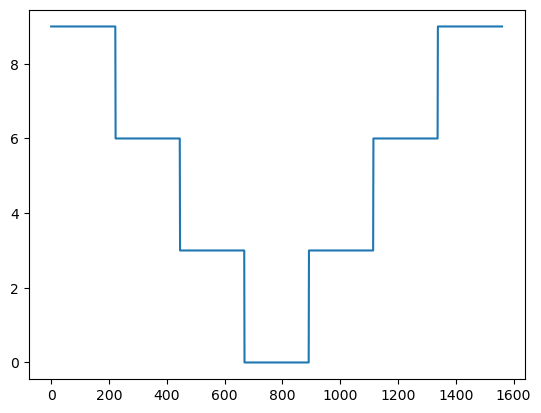

In [722]:
plt.plot(sigma)

In [723]:
variogram_parameters = {"sill": 0.8, "range": 10000, "nugget": 0.2}
nnear = 24

interpolator = mergeplg.interpolate.InterpolateOrdinaryKriging(
    ds_grid=ds_rad, # can be replaced with a custom grid
    ds_gauges=ds_gauges_transformed,
    full_line=False,
    variogram_parameters=variogram_parameters,
    nnear=nnear,
)

interp = interpolator(
    da_gauges=ds_gauges_transformed.rainfall_amount.isel(time=0),
    da_gauges_sigma=ds_gauges_transformed.sigma.isel(time=0)
)


Text(0.5, 1.0, 'gauges_transform')

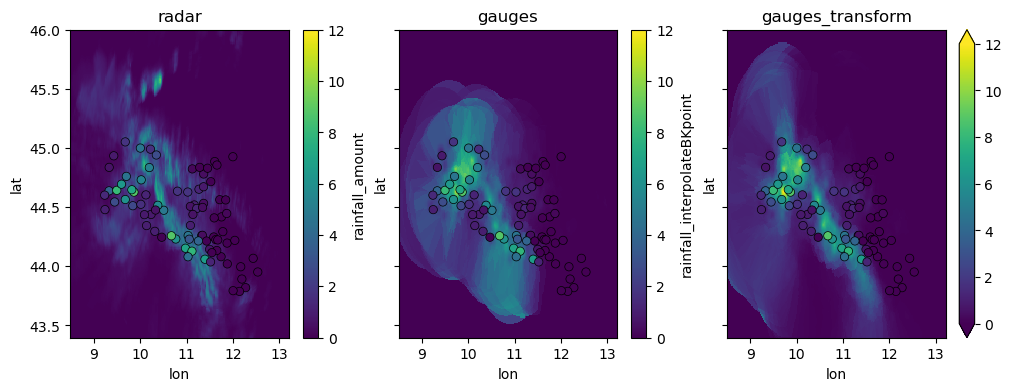

In [724]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4), sharex=True, sharey=True)
vmin = 0
vmax= 12
ds_rad.rainfall_amount.isel(time = t_target).plot(ax=ax[0], vmin=vmin, vmax=vmax)
ds_rad.rainfall_interpolateBKpoint.isel(time = t_target).plot(ax=ax[1], vmin=vmin, vmax=vmax)
interp.plot(ax=ax[2], vmin=vmin, vmax=vmax)

for i in range(3):
    ax[i].scatter(
        ds_gauges_test.longitude, 
        ds_gauges_test.latitude, 
        c=ds_gauges_test.isel(time=t_target).rainfall_amount, 
        vmin=0, 
        vmax=vmax,
        edgecolors='black',  # Add a black outline
        linewidth=0.5        # Adjust the thickness of the outline
    )

ax[0].set_title('radar')
ax[1].set_title('gauges')
ax[2].set_title('gauges_transform')

In [725]:
get_grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad,
    da_point_data=ds_gauges_test.rename({'latitude':'lat', 'longitude':'lon'}),
    nnear=1,
    stat="best",
)

ds_gauges_test_t = ds_gauges_test.isel(time = t_target)

ds_gauges_test_t['rainfall_radar'] = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_amount.isel(time = [t_target]),
    da_point_data=ds_gauges_test.rename({'latitude':'lat', 'longitude':'lon'}).rainfall_amount,
)

ds_gauges_test_t['rainfall_gauges']  = get_grid_at_points(
    da_gridded_data=ds_rad.rainfall_interpolateBKpoint.isel(time = [t_target]),
    da_point_data=ds_gauges_test.rename({'latitude':'lat', 'longitude':'lon'}).rainfall_amount,
)

ds_gauges_test_t['rainfall_gauges_advection']  = get_grid_at_points(
    da_gridded_data=interp,
    da_point_data=ds_gauges_test.rename({'latitude':'lat', 'longitude':'lon'}).rainfall_amount,
)

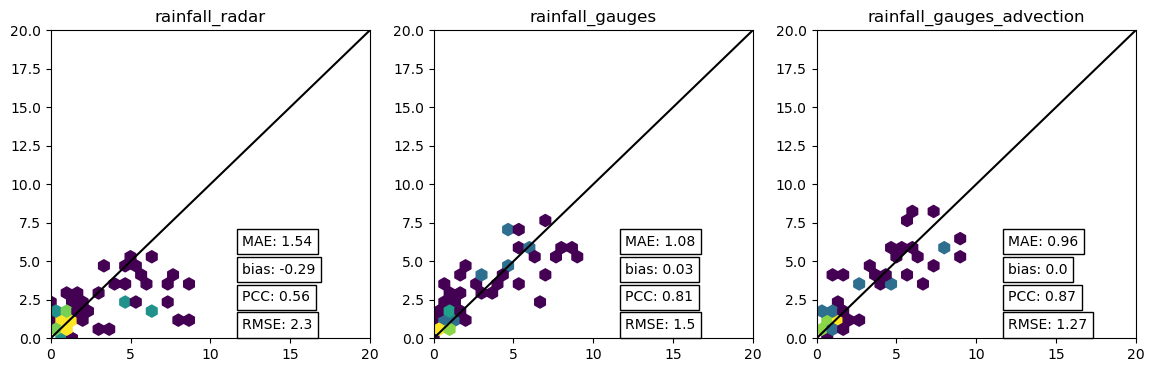

In [726]:
max_ext = 20
extent = [0, max_ext, 0, max_ext]
gridsize = 30

pred_models = [
    ds_gauges_test_t.rainfall_radar,
    ds_gauges_test_t.rainfall_gauges,
    ds_gauges_test_t.rainfall_gauges_advection,
]
fig, ax = plt.subplots(1, len(pred_models), figsize=(14, 4))
ground = ds_gauges_test_t.rainfall_amount.data
for i in range(len(pred_models)):
    tar = pred_models[i].data.T.ravel()

    keep = (ground > 0.1) & (tar > 0.1)

    ax[i].hexbin(
        ground[keep], tar[keep], mincnt=1, extent=extent, gridsize=gridsize, bins="log"
    )
    
    ax[i].text(
        0.6,
        0.03,
        "RMSE: " + str(round(np.sqrt(np.mean((ground[keep] - tar[keep]) ** 2)), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.12,
        "PCC: " + str(round(np.corrcoef(ground[keep], tar[keep])[0, 1], 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.21,
        "bias: "
        + str(round(np.mean(tar[keep] - ground[keep]) / np.mean(ground[keep]), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].text(
        0.6,
        0.3,
        "MAE: " + str(round(np.mean(np.abs(tar[keep] - ground[keep])), 2)),
        bbox={"facecolor": "white", "edgecolor": "black"},
        transform=ax[i].transAxes,
    )
    ax[i].plot([0, extent[1]], [0, extent[1]], "k")

    ax[i].set_title(pred_models[i].name)
    ax[i].set_xlim(0, extent[1])
    ax[i].set_ylim(0, extent[1])

# Function:
input
- standard OK, but with several timesteps
- time_sel 'end', 'mid', 'timestep_t'
- motion field from pysteps
- varigram + sigma time

functions does
- transform coords along motion field
- create sigma array

return
- decired timestep